# Factor Momentum (Ehsani & Linnainmaa 2022)

Individual-stock momentum is usually presented as a cross-sectional ranking of *names*. Ehsani & Linnainmaa (2022) argue that most of that premium is inherited from **momentum in the underlying systematic factors** those names load on:

$$R_{i,t} = \alpha_i + \sum_k \beta_{ik}\, F_{k,t} + \varepsilon_{i,t}$$

If the $F_k$ themselves are positively autocorrelated, then a stock that loaded on a recently-winning factor *looks* like a winner even if its residual $\varepsilon_i$ has no momentum at all. The testable implication is a spanning regression: once you control for a portfolio that times the factors, the classical UMD (winners-minus-losers) alpha should collapse.

This notebook reconstructs that argument on Ken French's published monthly factors rather than on individual stocks. That is a deliberate restriction: it tests the *factor-level* half of the paper (do factors have momentum, and does that portfolio span UMD?) and does not re-estimate stock-level $\beta_{ik}$. The payoff is a century of data and a sharp, falsifiable claim.

1. **Data** — Fama–French factors plus short- and long-term reversal, from the same Ken French library already cached in `data_cache/`
2. **Mechanism** — per-factor AR(1) and time-series momentum on a 12-month trailing return
3. **FactorMom portfolio** — equal-weight combination of those timing strategies
4. **Spanning tests** — UMD on FactorMom, and the reverse, on both the 1931– and 1963– samples, followed by a check that the result comes from *timing* the factors and not from simply holding them
5. **Crash window** — 2009 V-rebound, where Daniel & Moskowitz (2016) stock-momentum crashes


In [1]:
import io
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
from IPython.display import display
from scipy import stats

CACHE = Path("data_cache")
CACHE.mkdir(exist_ok=True)
MONTHS = 12

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")


## 1. Ken French factor library

Returns are published in percent; we convert to decimals. The first monthly block of each ZIP is the value-weighted factor series. Cached pickles from the sibling Fama–French notebooks are reused as-is so this file does not re-download what you already have.

The **base factors** used to build FactorMom deliberately exclude UMD / Mom. Including the thing you are trying to explain in the explanatory portfolio would make the spanning test tautological.


In [2]:
FF_BASE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
FF_FILES = {
    "FF3": "F-F_Research_Data_Factors_CSV.zip",
    "FF5": "F-F_Research_Data_5_Factors_2x3_CSV.zip",
    "MOM": "F-F_Momentum_Factor_CSV.zip",
    "ST_REV": "F-F_ST_Reversal_Factor_CSV.zip",
    "LT_REV": "F-F_LT_Reversal_Factor_CSV.zip",
}


def month_end_index(idx):
    p = idx if isinstance(idx, pd.PeriodIndex) else pd.DatetimeIndex(idx).to_period("M")
    return p.to_timestamp(how="end").normalize()


def _parse_ff_csv(text: str) -> list:
    lines = text.splitlines()
    blocks, cur, header = [], [], None
    for ln in lines:
        parts = [p.strip() for p in ln.split(",")]
        if len(parts) > 1 and parts[0] == "" and any(p for p in parts[1:]):
            if cur:
                blocks.append((header, cur))
                cur = []
            header = parts[1:]
            continue
        if header and parts[0][:6].isdigit() and len(parts[0]) in (6, 8):
            try:
                cur.append([parts[0]] + [float(p) for p in parts[1:len(header) + 1]])
            except ValueError:
                continue
        elif cur:
            blocks.append((header, cur))
            cur = []
            header = None
    if cur:
        blocks.append((header, cur))

    out = []
    for header, rows in blocks:
        if not rows or len(rows[0][0]) != 6:
            continue
        df = pd.DataFrame(rows, columns=["date"] + list(header[: len(rows[0]) - 1]))
        df["date"] = pd.to_datetime(df["date"], format="%Y%m").dt.to_period("M")
        out.append(df.set_index("date").astype(float))
    return out


def load_ff(key: str) -> pd.DataFrame:
    cache = CACHE / f"ff_{key}.pkl"
    if cache.exists():
        return pd.read_pickle(cache)

    url = FF_BASE + FF_FILES[key]
    raw = requests.get(url, timeout=60, headers={"User-Agent": "Mozilla/5.0 (research notebook)"})
    raw.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(raw.content)) as z:
        name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
        text = z.read(name).decode("latin-1")
    blocks = _parse_ff_csv(text)
    df = blocks[0] if len(blocks[0]) >= 400 else max(blocks, key=len)
    df = df.replace([-99.99, -999.0], np.nan) / 100.0
    df.columns = [str(c).strip() for c in df.columns]
    df.index = month_end_index(df.index)
    pd.to_pickle(df, cache)
    return df


ff3 = load_ff("FF3")
ff5 = load_ff("FF5")
mom = load_ff("MOM")
st_rev = load_ff("ST_REV")
lt_rev = load_ff("LT_REV")
mom.columns = ["Mom"]
st_rev.columns = ["ST_Rev"]
lt_rev.columns = ["LT_Rev"]

# Long sample: FF3 factors + reversals, 1927– (Mom starts Jan 1927)
long_factors = (
    ff3[["Mkt-RF", "SMB", "HML"]]
    .join(st_rev)
    .join(lt_rev)
    .join(mom)
    .dropna()
)
# Short sample: FF5 + reversals, 1963–
short_factors = (
    ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
    .join(st_rev)
    .join(lt_rev)
    .join(mom)
    .dropna()
)

print("Long sample  (FF3 + reversals):", f"{long_factors.index.min():%Y-%m} → {long_factors.index.max():%Y-%m}",
      f"({len(long_factors)} months, {len(long_factors) / MONTHS:.1f} years)")
print("Short sample (FF5 + reversals):", f"{short_factors.index.min():%Y-%m} → {short_factors.index.max():%Y-%m}",
      f"({len(short_factors)} months, {len(short_factors) / MONTHS:.1f} years)")
print("Long-sample columns :", list(long_factors.columns))
print("Short-sample columns:", list(short_factors.columns))
print(f"Annualized Sharpe required for t = 2, long sample : {2 / np.sqrt(len(long_factors) / MONTHS):.2f}")
print(f"Annualized Sharpe required for t = 2, short sample: {2 / np.sqrt(len(short_factors) / MONTHS):.2f}")


Long sample  (FF3 + reversals): 1931-01 → 2026-06 (1146 months, 95.5 years)
Short sample (FF5 + reversals): 1963-07 → 2026-06 (756 months, 63.0 years)
Long-sample columns : ['Mkt-RF', 'SMB', 'HML', 'ST_Rev', 'LT_Rev', 'Mom']
Short-sample columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'ST_Rev', 'LT_Rev', 'Mom']
Annualized Sharpe required for t = 2, long sample : 0.20
Annualized Sharpe required for t = 2, short sample: 0.25


## 2. Do the factors themselves have momentum?

If factor $k$ is positively autocorrelated, last year's factor return is a useful forecast of this month's. The AR(1)

$$F_{k,t} = a_k + \rho_k F_{k,t-1} + u_{k,t}$$

is estimated with Newey–West standard errors (12 lags, matching the overlapping annual signal used below). $\rho_k > 0$ is the mechanical ingredient of factor momentum; it is not yet a trading strategy.


In [3]:
def ar1_table(factors: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in factors.columns:
        y = factors[col].iloc[1:]
        x = sm.add_constant(factors[col].shift(1).iloc[1:])
        fit = sm.OLS(y, x, missing="drop").fit(cov_type="HAC", cov_kwds={"maxlags": 12})
        rho, se, t_stat, p_value = fit.params.iloc[1], fit.bse.iloc[1], fit.tvalues.iloc[1], fit.pvalues.iloc[1]
        rows.append({
            "AR(1) ρ": rho,
            "HAC SE": se,
            "t-stat": t_stat,
            "p-value": p_value,
            "Ann. mean": MONTHS * factors[col].mean(),
            "Ann. vol": np.sqrt(MONTHS) * factors[col].std(),
        })
    table = pd.DataFrame(rows, index=factors.columns)
    shown = table.copy()
    shown["AR(1) ρ"] = table["AR(1) ρ"].map(lambda v: f"{v:.3f}")
    shown["HAC SE"] = table["HAC SE"].map(lambda v: f"{v:.3f}")
    shown["t-stat"] = table["t-stat"].map(lambda v: f"{v:.2f}")
    shown["p-value"] = table["p-value"].map(lambda v: f"{v:.3f}")
    shown["Ann. mean"] = table["Ann. mean"].map(lambda v: f"{100 * v:.1f}%")
    shown["Ann. vol"] = table["Ann. vol"].map(lambda v: f"{100 * v:.1f}%")
    return shown


print("Long sample — monthly AR(1)")
display(ar1_table(long_factors))
print("Short sample — monthly AR(1)")
display(ar1_table(short_factors))


Long sample — monthly AR(1)


,AR(1) ρ,HAC SE,t-stat,p-value,Ann. mean,Ann. vol
Mkt-RF,0.084,0.060,1.42,0.156,8.6%,18.2%
SMB,0.049,0.048,1.03,0.305,2.6%,10.9%
HML,0.200,0.067,3.01,0.003,4.5%,12.4%
ST_Rev,0.025,0.049,0.51,0.612,8.3%,12.0%
LT_Rev,0.236,0.085,2.78,0.005,3.4%,12.0%
Mom,0.078,0.091,0.85,0.395,6.8%,16.3%


Short sample — monthly AR(1)


,AR(1) ρ,HAC SE,t-stat,p-value,Ann. mean,Ann. vol
Mkt-RF,0.041,0.041,0.99,0.321,7.2%,15.5%
SMB,0.049,0.050,0.99,0.324,2.2%,10.5%
HML,0.157,0.036,4.43,0.000,3.6%,10.3%
RMW,0.168,0.046,3.65,0.000,2.9%,7.8%
CMA,0.130,0.044,2.98,0.003,2.9%,7.2%
ST_Rev,-0.041,0.049,-0.83,0.406,4.6%,11.0%
LT_Rev,0.153,0.040,3.87,0.000,2.7%,9.2%
Mom,0.036,0.075,0.48,0.629,7.4%,14.5%


## 3. Time-series momentum on each factor

The trading rule is Moskowitz–Ooi–Pedersen (2012) applied to factor returns rather than asset prices. The position in factor $k$ at month $t$ is the sign of its trailing 12-month return, formed on information through $t-1$:

$$s_{k,t} = \operatorname{sign}\!\left(\sum_{j=1}^{12} F_{k,t-j}\right), \qquad r^{\text{TS}}_{k,t} = s_{k,t}\, F_{k,t}$$

The `.shift(1)` on the rolling sum is the entire difference between a valid backtest and look-ahead. **Mom is excluded from the timed set** and reserved as the left-hand-side spanning target.

The **FactorMom** portfolio is the equal-weight average of the individual timing strategies, which is the paper's simplest aggregator and does not require estimating a covariance matrix of factor returns:

$$r^{\text{FM}}_{t} = \frac{1}{K}\sum_{k=1}^{K} r^{\text{TS}}_{k,t}$$


In [4]:
def factor_tsmom(factors: pd.DataFrame, lookback: int = 12) -> pd.DataFrame:
    # Causal 12-month sign timing of each column. Leading lookback rows are NaN.
    trailing = factors.rolling(lookback).sum().shift(1)
    return np.sign(trailing) * factors


def timed_and_portfolios(panel: pd.DataFrame):
    base = panel.drop(columns=["Mom"])
    timed = factor_tsmom(base).dropna()
    factor_mom = timed.mean(axis=1).rename("FactorMom")
    umd = panel["Mom"].reindex(factor_mom.index).rename("UMD")
    return timed, factor_mom, umd


timed_long, fm_long, umd_long = timed_and_portfolios(long_factors)
timed_short, fm_short, umd_short = timed_and_portfolios(short_factors)

print(f"Long  FactorMom: {fm_long.index.min():%Y-%m} → {fm_long.index.max():%Y-%m}  ({len(fm_long)} months)")
print(f"Short FactorMom: {fm_short.index.min():%Y-%m} → {fm_short.index.max():%Y-%m}  ({len(fm_short)} months)")


Long  FactorMom: 1932-01 → 2026-06  (1134 months)
Short FactorMom: 1964-07 → 2026-06  (744 months)


### Risk statistics

Monthly analogues of the daily helpers in `momentum_strategies.ipynb`. Sharpe, Sortino and HAC $t$-statistics are annualized with $\sqrt{12}$; Calmar uses geometric CAGR. Drawdown-length statistics count only episodes that trough below **–10%** — a deeper threshold than the daily notebook's 5%, because a 5% dip is a quiet month in a 15–20% vol factor.


In [5]:
def newey_west_tstat(returns: pd.Series, lags: int = 12) -> tuple:
    r = returns.to_numpy(dtype=float)
    T = len(r)
    e = r - r.mean()
    var = e @ e / T
    for lag in range(1, lags + 1):
        var += 2 * (1 - lag / (lags + 1)) * (e[lag:] @ e[:-lag]) / T
    t_stat = r.mean() / np.sqrt(var / T)
    return t_stat, 2 * stats.norm.sf(abs(t_stat))


def performance_stats(returns: pd.Series, depth: float = 0.10) -> dict:
    wealth = (1 + returns).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    cagr = wealth.iloc[-1] ** (MONTHS / len(returns)) - 1
    max_dd = drawdown.min()
    downside = np.sqrt((returns.clip(upper=0) ** 2).mean())
    underwater = wealth < peak
    runs = underwater.ne(underwater.shift()).cumsum()
    lengths = underwater.groupby(runs).sum()
    material = lengths[drawdown.groupby(runs).min() <= -depth]
    t_stat, p_value = newey_west_tstat(returns)
    return {
        "Ann. Return": cagr,
        "Ann. Vol": returns.std() * np.sqrt(MONTHS),
        "Sharpe": np.sqrt(MONTHS) * returns.mean() / returns.std(),
        "Sortino": np.sqrt(MONTHS) * returns.mean() / downside,
        "Max DD": max_dd,
        "Calmar": cagr / abs(max_dd),
        "HAC t-stat": t_stat,
        "p-value": p_value,
        "Avg DD (months)": material.mean() if len(material) else 0.0,
        "Longest DD (months)": material.max() if len(material) else 0.0,
    }


def stats_table(strategies: dict) -> pd.DataFrame:
    table = pd.DataFrame([performance_stats(r) for r in strategies.values()], index=list(strategies))
    formatted = table.copy()
    for col in ("Ann. Return", "Ann. Vol", "Max DD"):
        formatted[col] = table[col].map(lambda v: f"{100 * v:.1f}%")
    for col in ("Sharpe", "Sortino", "Calmar", "HAC t-stat"):
        formatted[col] = table[col].map(lambda v: f"{v:.2f}")
    formatted["p-value"] = table["p-value"].map(lambda v: f"{v:.3f}")
    for col in ("Avg DD (months)", "Longest DD (months)"):
        formatted[col] = table[col].map(lambda v: f"{v:.0f}")
    return formatted.T


def per_factor_timing_table(timed: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in timed.columns:
        r = timed[col]
        t_stat, p_value = newey_west_tstat(r)
        rows.append({
            "Ann. Return": MONTHS * r.mean(),
            "Ann. Vol": np.sqrt(MONTHS) * r.std(),
            "Sharpe": np.sqrt(MONTHS) * r.mean() / r.std(),
            "HAC t-stat": t_stat,
            "p-value": p_value,
            "Hit rate": (r > 0).mean(),
        })
    table = pd.DataFrame(rows, index=timed.columns)
    shown = table.copy()
    shown["Ann. Return"] = table["Ann. Return"].map(lambda v: f"{100 * v:.1f}%")
    shown["Ann. Vol"] = table["Ann. Vol"].map(lambda v: f"{100 * v:.1f}%")
    shown["Sharpe"] = table["Sharpe"].map(lambda v: f"{v:.2f}")
    shown["HAC t-stat"] = table["HAC t-stat"].map(lambda v: f"{v:.2f}")
    shown["p-value"] = table["p-value"].map(lambda v: f"{v:.3f}")
    shown["Hit rate"] = table["Hit rate"].map(lambda v: f"{100 * v:.1f}%")
    return shown


print("Long sample — per-factor 12-month TSMOM")
display(per_factor_timing_table(timed_long))
print("Long sample — FactorMom vs UMD vs market")
display(stats_table({
    "FactorMom (FF3 + rev.)": fm_long,
    "UMD": umd_long,
    "Mkt-RF": long_factors["Mkt-RF"].reindex(fm_long.index),
}))


Long sample — per-factor 12-month TSMOM


,Ann. Return,Ann. Vol,Sharpe,HAC t-stat,p-value,Hit rate
Mkt-RF,6.8%,17.8%,0.38,4.32,0.000,59.5%
SMB,3.2%,10.9%,0.30,2.84,0.004,53.7%
HML,3.8%,12.3%,0.31,3.23,0.001,56.9%
ST_Rev,5.7%,11.7%,0.49,3.94,0.000,56.6%
LT_Rev,4.5%,11.9%,0.38,3.30,0.001,55.1%


Long sample — FactorMom vs UMD vs market


,FactorMom (FF3 + rev.),UMD,Mkt-RF
Ann. Return,4.7%,5.2%,7.9%
Ann. Vol,7.0%,16.0%,17.7%
Sharpe,0.69,0.41,0.52
Sortino,1.19,0.53,0.81
Max DD,-23.9%,-78.5%,-55.7%
Calmar,0.20,0.07,0.14
HAC t-stat,6.80,4.15,4.96
p-value,0.000,0.000,0.000
Avg DD (months),29,47,36
Longest DD (months),65,293,172


In [6]:
print("Short sample — per-factor 12-month TSMOM")
display(per_factor_timing_table(timed_short))
print("Short sample — FactorMom vs UMD vs market")
display(stats_table({
    "FactorMom (FF5 + rev.)": fm_short,
    "UMD": umd_short,
    "Mkt-RF": short_factors["Mkt-RF"].reindex(fm_short.index),
}))


Short sample — per-factor 12-month TSMOM


,Ann. Return,Ann. Vol,Sharpe,HAC t-stat,p-value,Hit rate
Mkt-RF,6.4%,15.6%,0.41,3.82,0.000,59.3%
SMB,3.5%,10.5%,0.33,2.58,0.010,53.8%
HML,3.0%,10.4%,0.29,2.12,0.034,55.5%
RMW,3.3%,7.8%,0.42,3.36,0.001,55.1%
CMA,2.3%,7.2%,0.31,2.29,0.022,54.0%
ST_Rev,2.9%,11.1%,0.26,1.89,0.059,53.4%
LT_Rev,4.2%,9.2%,0.46,3.56,0.000,55.8%


Short sample — FactorMom vs UMD vs market


,FactorMom (FF5 + rev.),UMD,Mkt-RF
Ann. Return,3.6%,6.5%,6.0%
Ann. Vol,4.9%,14.6%,15.6%
Sharpe,0.74,0.51,0.46
Sortino,1.19,0.71,0.67
Max DD,-14.0%,-57.8%,-55.8%
Calmar,0.26,0.11,0.11
HAC t-stat,6.59,4.00,3.49
p-value,0.000,0.000,0.000
Avg DD (months),25,33,50
Longest DD (months),28,211,172


## 4. Spanning tests: does FactorMom subsume UMD?

The paper's headline is an *asymmetric* spanning result. Estimate, with Newey–West errors,

$$\text{UMD}_t = \alpha + \beta\, r^{\text{FM}}_t + \varepsilon_t \tag{A}$$

$$r^{\text{FM}}_t = \alpha' + \beta'\, \text{UMD}_t + u_t \tag{B}$$

If individual-stock momentum is inherited from factor persistence, $\alpha$ in (A) should be indistinguishable from zero (UMD adds nothing once FactorMom is in the regression) while $\alpha'$ in (B) should remain positive (FactorMom is not just UMD in disguise).

A third specification, (A+), puts the *raw* (un-timed) base factors on the right-hand side as well, so that any remaining $\alpha$ cannot be attributed to static factor exposure of UMD.


In [7]:
def spanning_row(y: pd.Series, X: pd.DataFrame, spec: str) -> dict:
    aligned = pd.concat([y.rename("y"), X], axis=1, join="inner").dropna()
    fit = sm.OLS(aligned["y"], sm.add_constant(aligned.drop(columns="y"))).fit(
        cov_type="HAC", cov_kwds={"maxlags": 12}
    )
    alpha = fit.params["const"]
    slope_name = [c for c in fit.params.index if c != "const"][0]
    return {
        "Spec": spec,
        "N": int(fit.nobs),
        "α (monthly)": alpha,
        "α (ann.)": MONTHS * alpha,
        "t(α)": fit.tvalues["const"],
        "p(α)": fit.pvalues["const"],
        "β (primary)": fit.params[slope_name],
        "t(β)": fit.tvalues[slope_name],
        "R²": fit.rsquared,
    }


def spanning_table(fm: pd.Series, umd: pd.Series, raw_factors: pd.DataFrame) -> pd.DataFrame:
    raw = raw_factors.drop(columns=["Mom"]).reindex(fm.index)
    X_fm = fm.to_frame()
    X_umd = umd.to_frame()
    X_plus = pd.concat([fm, raw], axis=1)
    rows = [
        spanning_row(umd, X_fm, "UMD ~ FactorMom"),
        spanning_row(fm, X_umd, "FactorMom ~ UMD"),
        spanning_row(umd, X_plus, "UMD ~ FactorMom + raw factors"),
    ]
    table = pd.DataFrame(rows).set_index("Spec")
    shown = table.copy()
    shown["N"] = table["N"].map(lambda v: f"{v:.0f}")
    for col in ("α (monthly)", "α (ann.)", "β (primary)"):
        shown[col] = table[col].map(lambda v: f"{v:.4f}" if pd.notna(v) else "—")
    for col in ("t(α)", "t(β)"):
        shown[col] = table[col].map(lambda v: f"{v:.2f}" if pd.notna(v) else "—")
    shown["p(α)"] = table["p(α)"].map(lambda v: f"{v:.3f}")
    shown["R²"] = table["R²"].map(lambda v: f"{v:.3f}")
    return shown


print("Long sample spanning")
display(spanning_table(fm_long, umd_long, long_factors))
print("Short sample spanning")
display(spanning_table(fm_short, umd_short, short_factors))


Long sample spanning


,N,α (monthly),α (ann.),t(α),p(α),β (primary),t(β),R²
Spec,,,,,,,,
UMD ~ FactorMom,1134,0.0023,0.0272,1.49,0.135,0.8019,2.81,0.122
FactorMom ~ UMD,1134,0.0032,0.0381,4.52,0.000,0.1521,4.57,0.122
UMD ~ FactorMom + raw factors,1134,0.0054,0.0644,4.40,0.000,1.2943,13.53,0.482


Short sample spanning


,N,α (monthly),α (ann.),t(α),p(α),β (primary),t(β),R²
Spec,,,,,,,,
UMD ~ FactorMom,744,0.0015,0.0176,1.02,0.308,1.5368,8.01,0.272
FactorMom ~ UMD,744,0.0020,0.0236,4.14,0.000,0.1769,7.55,0.272
UMD ~ FactorMom + raw factors,744,0.0036,0.0433,2.34,0.019,1.6397,9.72,0.418


### Timing versus simply holding the factors

FactorMom's Sharpe and $t$-statistic above do not by themselves show that *timing* works. Every base factor has a positive unconditional premium, and a 12-month sign rule on a series with positive drift is long most of the time. A portfolio that is long two-thirds of the time in things that go up will earn a premium whether or not last year's return predicts anything.

Three checks separate the two:

1. **Passive benchmark.** The equal-weight portfolio of the same base factors, always long. If timing adds nothing, FactorMom is a diluted version of it.
2. **Conditional means.** Ehsani & Linnainmaa's own evidence: the average factor return in months following a positive trailing year against months following a negative one. The spread is tested on the monthly series (mean of factors with an up signal) − (mean of factors with a down signal), over months where both groups are non-empty.
3. **Spanning against the passive book.** FactorMom on Passive measures the timing alpha. UMD on Passive asks whether static factor exposure could have explained momentum without any timing at all.

In [8]:
def timing_vs_holding(panel: pd.DataFrame, fm: pd.Series, umd: pd.Series, label: str):
    base = panel.drop(columns=["Mom"])
    signal = np.sign(base.rolling(12).sum().shift(1)).reindex(fm.index)
    base = base.reindex(fm.index)
    passive = base.mean(axis=1).rename("Passive")

    ann_sr = lambda r: np.sqrt(MONTHS) * r.mean() / r.std()
    after_up = base.where(signal > 0)
    after_down = base.where(signal < 0)
    spread = (after_up.mean(axis=1) - after_down.mean(axis=1)).dropna()
    t_spread, p_spread = newey_west_tstat(spread)

    print(f"{label}: share of factor-months held long = {(signal > 0).to_numpy().mean():.0%}")
    display(pd.DataFrame({
        "FactorMom (timed)": {"Sharpe": f"{ann_sr(fm):.2f}", "Ann. mean": f"{100 * MONTHS * fm.mean():.1f}%", "Ann. vol": f"{100 * np.sqrt(MONTHS) * fm.std():.1f}%"},
        "Passive (always long)": {"Sharpe": f"{ann_sr(passive):.2f}", "Ann. mean": f"{100 * MONTHS * passive.mean():.1f}%", "Ann. vol": f"{100 * np.sqrt(MONTHS) * passive.std():.1f}%"},
    }))
    print(
        f"Avg annualized factor return after an up year: {100 * MONTHS * after_up.stack().mean():.1f}%   "
        f"after a down year: {100 * MONTHS * after_down.stack().mean():.1f}%\n"
        f"Up-minus-down spread: {100 * MONTHS * spread.mean():.1f}% a year, HAC t = {t_spread:.2f} (p = {p_spread:.3f}, {len(spread)} months), "
        f"corr(FactorMom, Passive) = {fm.corr(passive):.2f}"
    )
    rows = [
        spanning_row(fm, passive.to_frame(), "FactorMom ~ Passive"),
        spanning_row(passive, fm.to_frame(), "Passive ~ FactorMom"),
        spanning_row(umd, passive.to_frame(), "UMD ~ Passive"),
        spanning_row(umd, pd.concat([fm, passive], axis=1), "UMD ~ FactorMom + Passive"),
    ]
    table = pd.DataFrame(rows).set_index("Spec")[["α (ann.)", "t(α)", "p(α)", "β (primary)", "R²"]]
    shown = table.copy()
    shown["α (ann.)"] = table["α (ann.)"].map(lambda v: f"{100 * v:.1f}%")
    for col in ("t(α)", "β (primary)", "R²"):
        shown[col] = table[col].map(lambda v: f"{v:.2f}")
    shown["p(α)"] = table["p(α)"].map(lambda v: f"{v:.3f}")
    display(shown)


timing_vs_holding(long_factors, fm_long, umd_long, "Long sample")
timing_vs_holding(short_factors, fm_short, umd_short, "Short sample")

Long sample: share of factor-months held long = 66%


,FactorMom (timed),Passive (always long)
Sharpe,0.69,0.68
Ann. mean,4.8%,5.5%
Ann. vol,7.0%,8.1%


Avg annualized factor return after an up year: 7.9%   after a down year: 1.1%
Up-minus-down spread: 7.5% a year, HAC t = 5.40 (p = 0.000, 918 months), corr(FactorMom, Passive) = 0.33


,α (ann.),t(α),p(α),β (primary),R²
Spec,,,,,
FactorMom ~ Passive,3.2%,4.67,0.000,0.28,0.11
Passive ~ FactorMom,3.7%,4.22,0.000,0.39,0.11
UMD ~ Passive,11.2%,8.03,0.000,-0.84,0.18
UMD ~ FactorMom + Passive,7.1%,5.14,0.000,1.26,0.45


Short sample: share of factor-months held long = 65%


,FactorMom (timed),Passive (always long)
Sharpe,0.74,0.81
Ann. mean,3.7%,3.7%
Ann. vol,4.9%,4.6%


Avg annualized factor return after an up year: 5.7%   after a down year: 0.1%
Up-minus-down spread: 6.4% a year, HAC t = 5.13 (p = 0.000, 700 months), corr(FactorMom, Passive) = 0.10


,α (ann.),t(α),p(α),β (primary),R²
Spec,,,,,
FactorMom ~ Passive,3.3%,5.66,0.000,0.11,0.01
Passive ~ FactorMom,3.4%,5.62,0.000,0.10,0.01
UMD ~ Passive,10.7%,6.02,0.000,-0.89,0.08
UMD ~ FactorMom + Passive,5.4%,3.38,0.001,1.64,0.39


## 5. Equity curves

Cumulative wealth of FactorMom against UMD and the market, log scale, starting at 1. The two samples are plotted separately so the extra factors in the 1963– panel are not mixed with the longer, thinner FF3 set.


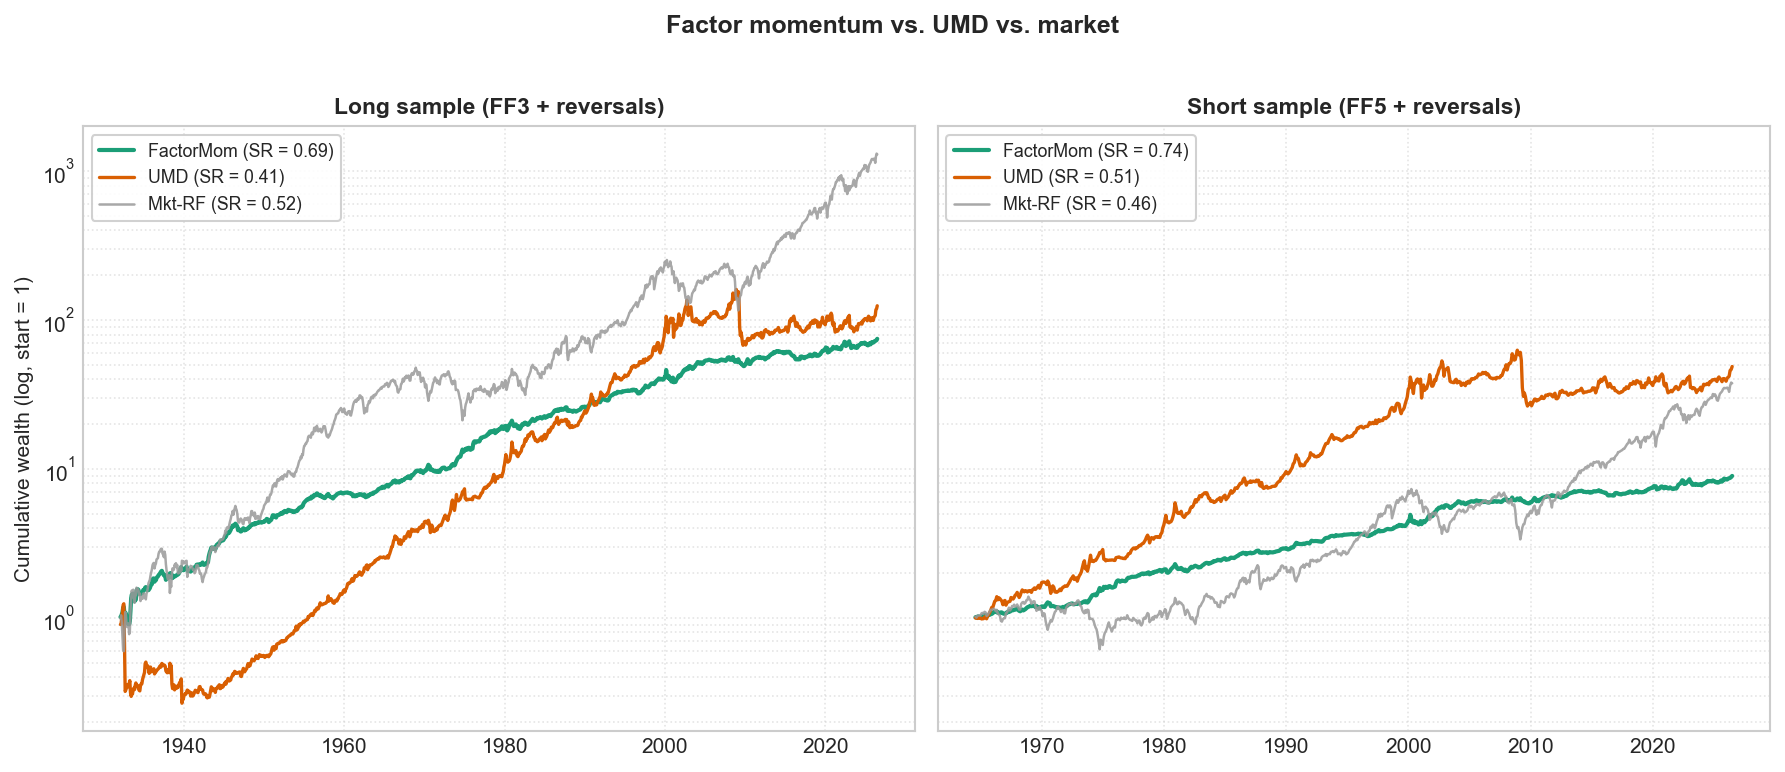

In [9]:
def wealth(r: pd.Series) -> pd.Series:
    return (1 + r).cumprod()


fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, sharey=True)
for ax, title, fm, umd, mkt in (
    (axes[0], "Long sample (FF3 + reversals)", fm_long, umd_long, long_factors["Mkt-RF"].reindex(fm_long.index)),
    (axes[1], "Short sample (FF5 + reversals)", fm_short, umd_short, short_factors["Mkt-RF"].reindex(fm_short.index)),
):
    ax.plot(wealth(fm), label=f"FactorMom (SR = {np.sqrt(MONTHS) * fm.mean() / fm.std():.2f})", color="#1b9e77", lw=2.0)
    ax.plot(wealth(umd), label=f"UMD (SR = {np.sqrt(MONTHS) * umd.mean() / umd.std():.2f})", color="#d95f02", lw=1.6)
    ax.plot(wealth(mkt), label=f"Mkt-RF (SR = {np.sqrt(MONTHS) * mkt.mean() / mkt.std():.2f})", color="#999999", lw=1.2, alpha=0.85)
    ax.set_yscale("log")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8.5, frameon=True, facecolor="white", framealpha=0.9)
    ax.grid(True, which="both", ls=":", alpha=0.5)
axes[0].set_ylabel("Cumulative wealth (log, start = 1)")
fig.suptitle("Factor momentum vs. UMD vs. market", fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 6. The 2009 momentum crash

Daniel & Moskowitz (2016) document that UMD loses on the order of −40% in spring 2009, when the short leg of distressed losers squeezes on the V-rebound. FactorMom's market-timing sleeve is *also* short the market after a 12-month collapse, so it is not immune. The question is whether the *other* timed factors (value, profitability, investment, reversals) diversify that crash, which is the economic content of the spanning result.

The window below is March–May 2009, the three months Daniel & Moskowitz highlight. Cumulative returns, not annualized.


In [10]:
CRASH = slice("2009-03-01", "2009-05-31")


def crash_table(timed: pd.DataFrame, fm: pd.Series, umd: pd.Series, mkt: pd.Series) -> pd.DataFrame:
    pieces = {"FactorMom": fm, "UMD": umd, "Mkt-RF": mkt, **{c: timed[c] for c in timed.columns}}
    rows = {}
    for name, r in pieces.items():
        window = r.loc[CRASH]
        rows[name] = {
            "Mar–May 2009": (1 + window).prod() - 1,
            "Worst month": window.min(),
            "Worst month date": window.idxmin().strftime("%Y-%m") if len(window) else "—",
        }
    table = pd.DataFrame(rows).T
    shown = table.copy()
    shown["Mar–May 2009"] = table["Mar–May 2009"].map(lambda v: f"{100 * v:.1f}%")
    shown["Worst month"] = table["Worst month"].map(lambda v: f"{100 * v:.1f}%")
    return shown


print("Short sample — 2009 crash window (FF5 FactorMom has more sleeves to diversify)")
display(crash_table(
    timed_short, fm_short, umd_short,
    short_factors["Mkt-RF"].reindex(fm_short.index),
))


Short sample — 2009 crash window (FF5 FactorMom has more sleeves to diversify)


,Mar–May 2009,Worst month,Worst month date
FactorMom,-4.8%,-3.3%,2009-03
UMD,-49.4%,-34.4%,2009-04
Mkt-RF,-22.5%,-10.2%,2009-04
SMB,5.4%,-2.2%,2009-05
HML,-9.0%,-5.4%,2009-04
RMW,-2.1%,-2.6%,2009-03
CMA,-4.4%,-2.0%,2009-03
ST_Rev,5.8%,-3.1%,2009-03
LT_Rev,-5.1%,-3.5%,2009-03


### What the tests actually say

Read the spanning table before the equity curves. The curves will almost always make FactorMom look smoother than UMD — both because equal-weighting $K$ timed factors is a diversification step, and because UMD's 2009 crash is a single violent episode that dominates a 17-year daily sample but is one quarter in a 90-year monthly sample.

Five results are worth separating:

- **Monthly AR(1) is the wrong horizon for the trade.** HML, RMW, CMA and LT_Rev show significant $\rho$ at one month; Mkt-RF, SMB, ST_Rev and Mom do not. The 12-month sign timer is a different object: in the long sample every timed sleeve has $t > 2.8$, including the market. Short-term reversal is the instructive case — its AR(1) is indistinguishable from zero (it is a *reversal* factor), but its 12-month timer still earns Sharpe $0.49$. Do not read the AR(1) table as a ranking of which sleeves contribute.
- **The spanning asymmetry is the paper.** A large $\alpha$ in FactorMom ~ UMD with a collapsed $\alpha$ in UMD ~ FactorMom is the Ehsani–Linnainmaa result. On both samples that is what we get: UMD's intercept is insignificant once FactorMom is in the regression ($t = 1.49$ long, $t = 1.02$ short), while FactorMom's intercept against UMD stays highly significant ($t = 4.52$ and $4.14$). Specification (A+) — adding the *raw* un-timed factors — is a different question. It asks whether FactorMom spans the FF-orthogonal UMD residual, which is known to be larger than raw UMD because momentum's static tilts get stripped out. Restoration of $\alpha$ in (A+) is therefore not a contradiction of (A).
- **FactorMom's Sharpe is not evidence of timing; the conditional means and the spanning regressions are.** The timed portfolio is long about two-thirds of the time in factors with positive premia, and its Sharpe is no better than holding those factors passively ($0.69$ vs. $0.68$ long sample, $0.74$ vs. $0.81$ short). What survives a passive benchmark is this: factors earn $7.9\%$ a year after an up year and $1.1\%$ after a down year (spread $t = 5.4$; $5.7\%$ vs. $0.1\%$, $t = 5.1$ on the short sample), FactorMom has a $3.2$–$3.3\%$ annual alpha over the passive book ($t = 4.7$ and $5.7$), and the passive book leaves UMD's alpha at $11\%$ a year ($t > 6$) where FactorMom takes it to insignificance. Static factor exposure does not explain UMD. Factor *timing* does.
- **This uses 5–7 Ken French factors, not the ~20-factor zoo in the original paper.** A residual UMD alpha against a larger factor set could still go to zero even if (A+) does not here.
- **This is not a stock-level replication.** We never estimate $\beta_{ik}$ on individual names, so we cannot claim that "stock momentum disappears" in the sense of the paper's Table III. What we can claim is whether a portfolio that times published factors spans published UMD. That is the mechanism, tested at the level where the data are cleanest.

The look-ahead that would most easily manufacture a result here is using the 12-month sum *including* month $t$. Every timing series above is `rolling(12).sum().shift(1)`.
